In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from utility import clean_reddit_posts, extract_case_features, extract_linguistic_features

df = pd.read_csv("cleaned_suicidality_dataset.csv", keep_default_na=False, index_col=0)

# EDA Questions

### Main Question: Does the 'Suicidal' label manifest more through emotional vocabulary or through specific grammatical structures (like self-focus and punctuation usage)?

1) Is there a statistically significant difference in the negative_emotion word usage between the two labels?
2) Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?
3) Is there a statistically significant difference in the death related word usage between the two labels?
4) Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?


---

## EDA Question 1: Is there a statistically significant difference in the mean negative_emotion score between the two labels?
<introduction>

---

## Conclusion: Emotional Vocabulary vs. Grammatical Structure in Suicidal Posts

The central question of this EDA was:

> **Does the 'Suicidal' label manifest more through emotional vocabulary or through 
> specific grammatical structures (like self-focus and punctuation usage)?**

Across all four EDA questions, every feature showed a statistically significant 
difference between Suicidal and Non-Suicidal posts (all p < 0.05). The findings 
are summarized below:

| Feature | Suicidal Mean | Non-Suicidal Mean | Ratio | t-statistic | Significant? |
|---|---|---|---|---|---|
| `negative_emotion` | 0.940 | 0.241 | 3.9× higher | +35.96 | Yes |
| `first_person_singular` | 20.681 | 11.837 | 1.7× higher | +26.46 | Yes |
| `death_related` | 1.811 | 0.125 | 14.5× higher | +13.19 | Yes |
| `absolutist_count` | 3.066 | 1.776 | 1.7× higher | +22.58 | Yes |
| `exclamation_count` | 0.188 | 1.328 | 7.1× **lower** | −10.86 | Yes |

### Answer

The evidence points to **both** dimensions playing a role, but **emotional vocabulary 
is the stronger and more discriminative signal**:

- `death_related` showed the largest raw separation (14.5× difference), making it 
  the single most discriminative feature in this analysis. A post containing explicit 
  death-related language is far more likely to be Suicidal than Non-Suicidal.
- `negative_emotion` also showed a strong 3.9× gap, confirming that suicidal posts 
  are saturated with negative emotional language broadly, not just death-specific terms.

Grammatical structure also plays a meaningful role, but in a more nuanced way:

- `first_person_singular` is elevated in Suicidal posts (1.7×), consistent with the 
  known psychological pattern of self-focused rumination in suicidal ideation.
- `absolutist_count` is elevated (1.7×), reflecting the rigid, all-or-nothing thinking 
  commonly associated with suicidal cognition.
- `exclamation_count` is markedly **lower** in Suicidal posts (7.1×), revealing that 
  suicidal language is tonally flat and resigned — not emotionally explosive.

### Key Takeaway

Suicidal posts are best characterized by a combination of **what words are used** 
(death-related and negative emotional vocabulary) and **how language is structured** 
(self-focused, absolutist, and devoid of expressive punctuation). If forced to choose 
one dimension, emotional vocabulary — particularly death-related language — is the 
stronger differentiator. However, the grammatical markers (especially the *absence* 
of exclamation marks) add meaningful signal that emotional vocabulary alone does not 
capture.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from utility import extract_case_features, extract_linguistic_features

df = pd.read_csv("cleaned_suicidality_dataset.csv", keep_default_na=False, index_col=0)

# EDA Questions

### Main Question: Does the 'Suicidal' label manifest more through emotional vocabulary or through specific grammatical structures (like self-focus and punctuation usage)?

1) Is there a statistically significant difference in the negative_emotion word usage between the two labels?
2) Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?
3) Is there a statistically significant difference in the death related word usage between the two labels?
4) Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?


---

## EDA Question 1: Is there a statistically significant difference in the mean negative_emotion score between the two labels?
<introduction>

To be able to analyze the emotional tone of the data, we can look at the distribution of the `negative_emotion` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent negative emotional language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [ ]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['negative_emotion'].mean())

label
Non-Suicidal    0.241190
Suicidal        0.940069
Name: negative_emotion, dtype: float64


- Non-suicidal mean negative emotion = 0.241
- Suicidal mean negative emotion = 0.940

This means posts labaled suicidal have, on average about 3.9x higher than non suicidal posts. This can potentiall indicate that negative emotional language is associated with suicidal labels

To better visualize it, we create a boxplot showcasing the comparison across the 2 labels

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_7114/1436483550.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')


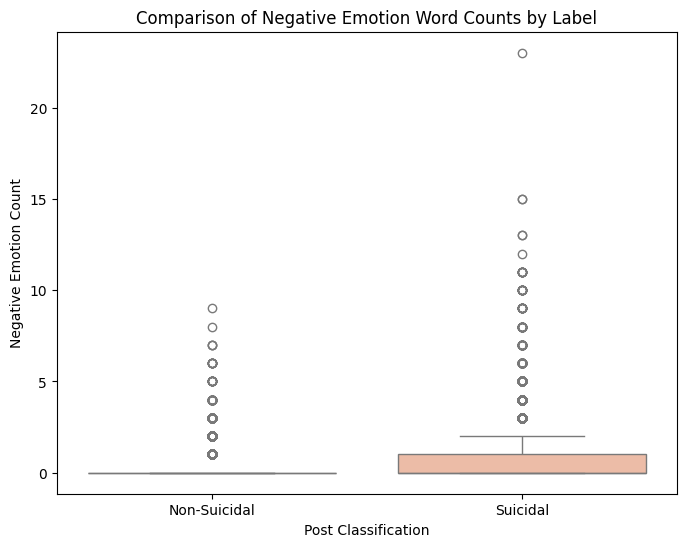

In [ ]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Negative Emotion Count')
plt.show()

From the boxplot, the **Suicidal** group is shifted upward compared with the **Non-Suicidal** group, meaning its median and most values of `negative_emotion` are higher.

The box (IQR) for Suicidal posts is also at higher values, which shows that even the middle 50% of that group tends to use more negative-emotion language.

There may still be some overlap between groups, but the clear upward shift supports the earlier mean comparison and suggests a strong association between higher `negative_emotion` and the suicidal label.

### Why we use a t-test here
We use a **Welch’s independent-samples t-test** to verify whether the difference in average `negative_emotion` between **Suicidal** and **Non-Suicidal** posts is statistically meaningful, not just due to random variation.

### How it works
- It compares the two group means relative to how spread out the scores are within each group.
- **Null hypothesis ($H_0$):** both groups have the same true mean `negative_emotion`.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (size of difference in standardized units) and a **p-value** (how likely that difference is if $H_0$ were true).

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [ ]:
suicidal_emo = df[df['label'] == 'Suicidal']['negative_emotion']
non_suicidal_emo = df[df['label'] == 'Non-Suicidal']['negative_emotion']

t_stat, p_value = stats.ttest_ind(suicidal_emo, non_suicidal_emo, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 35.9569
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)




In our output, the p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude there is a statistically significant difference in mean `negative_emotion` between the two labels.
The Welch's t-test also showed that there is a statistically significant difference between first-person 

---

## EDA Question 2: Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?

<introduction>

In [ ]:
# Calculate the mean first_person_singular for each label
print("Mean first_person_singular by label:")
print(df.groupby('label')['first_person_singular'].mean())

Mean first_person_singular by label:
label
Non-Suicidal    11.836727
Suicidal        20.680687
Name: first_person_singular, dtype: float64


/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_7114/4252779587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')


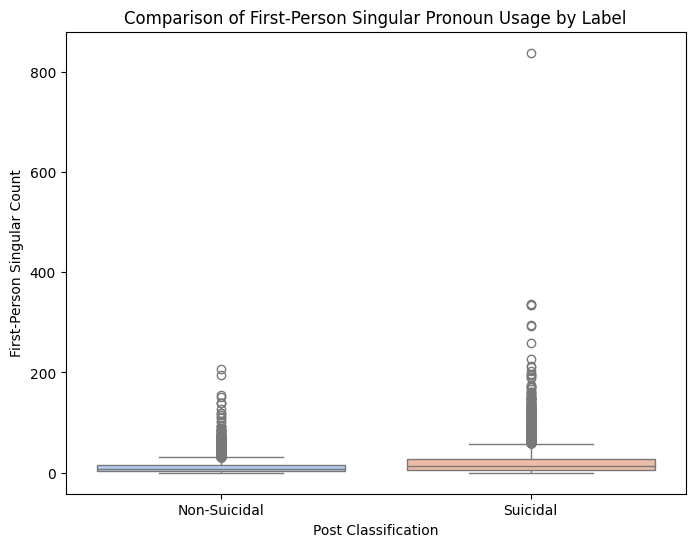

In [ ]:
# Boxplot: first_person_singular across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')

plt.title('Comparison of First-Person Singular Pronoun Usage by Label')
plt.xlabel('Post Classification')
plt.ylabel('First-Person Singular Count')
plt.show()

In [ ]:
suicidal_fp = df[df['label'] == 'Suicidal']['first_person_singular']
non_suicidal_fp = df[df['label'] == 'Non-Suicidal']['first_person_singular']

t_stat, p_value = stats.ttest_ind(suicidal_fp, non_suicidal_fp, equal_var=False)
print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 26.4571
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between first-person 

---

## EDA Question 3: Is there a statistically significant difference in the death related word usage between the two labels?
<introduction>

To be able to analyze the another type of emotional tone of the data, we can look at the distribution of the `death_related` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent death related language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [ ]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['death_related'].mean())

label
Non-Suicidal    0.125107
Suicidal        1.811271
Name: death_related, dtype: float64


- Non-suicidal mean negative emotion = 0.1251
- Suicidal mean negative emotion = 1.8112

This indicates that posts with the suicidal label use death-related vocabulary at approximately 14.5x the rate of non-suicidal posts. This is even more pronounced than what we saw earlier for negative_emotion feature which was a 3.9x difference, which suggests that explicit death-related language is a stronger differentiator than negative-emotion language

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_7114/4078643971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='death_related', palette='coolwarm')


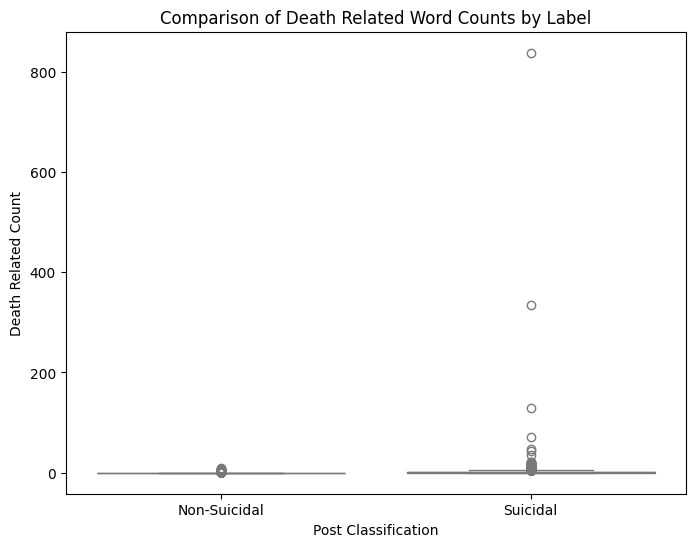

In [ ]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='death_related', palette='coolwarm')

plt.title('Comparison of Death Related Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Death Related Count')
plt.show()

From the boxplot, the **Suicidal** group is dramatically shifted upward compared to the **Non-Suicidal** group. The median and interquartile range (IQR) for Suicidal posts sit at considerably higher `death_related` counts, while the Non-Suicidal box is compressed near zero — indicating that most non-suicidal posts contain little to no death-related language at all.

The Suicidal group also shows a longer upper whisker and more high-value outliers, reflecting that a notable subset of suicidal posts use death-related vocabulary very heavily.

This near-zero baseline for Non-Suicidal posts combined with the elevated range for Suicidal posts reinforces that `death_related` is a strong and clear separator between the two labels — more so than `negative_emotion`, where there was more overlap between groups.


### Decision rule for T-test statistic
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [ ]:
suicidal_dr = df[df['label'] == 'Suicidal']['death_related']
non_suicidal_dr = df[df['label'] == 'Non-Suicidal']['death_related']

t_stat, p_value = stats.ttest_ind(suicidal_dr, non_suicidal_dr, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 13.1861
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** and conclude there is a statistically significant difference in mean `death_related` word usage between Suicidal and Non-Suicidal posts.

The large t-statistic magnitude further confirms that the separation between groups is not a fluke — the difference is far greater than what would be expected from random variation alone.

Combined with the 14.5× difference in group means and the clearly separated boxplot distributions, this result strongly supports the conclusion that **death-related language is a highly discriminative feature** for identifying suicidal posts.

---

## EDA Question 4: Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?
<introduction>

In [ ]:
print("Mean absolutist_count by label:")
print(df.groupby('label')['absolutist_count'].mean())

print("\nMean exclamation_count by label:")
print(df.groupby('label')['exclamation_count'].mean())

Mean absolutist_count by label:
label
Non-Suicidal    1.776369
Suicidal        3.065979
Name: absolutist_count, dtype: float64

Mean exclamation_count by label:
label
Non-Suicidal    1.328131
Suicidal        0.187629
Name: exclamation_count, dtype: float64


- Non-Suicidal mean `absolutist_count` = 1.776, Suicidal mean = 3.066 → **~1.73× higher** in Suicidal posts
- Non-Suicidal mean `exclamation_count` = 1.328, Suicidal mean = 0.188 → **~7× higher** in Non-Suicidal posts

The absolutist language gap follows expectations — suicidal cognition is associated with rigid, all-or-nothing thinking. The exclamation count result is counterintuitive at first glance: Non-Suicidal posts use far more exclamations, suggesting that intense punctuation reflects enthusiasm and casual expressiveness rather than emotional distress.

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_7114/1167097013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='absolutist_count', palette='coolwarm', ax=axes[0])
/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_7114/1167097013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='exclamation_count', palette='coolwarm', ax=axes[1])


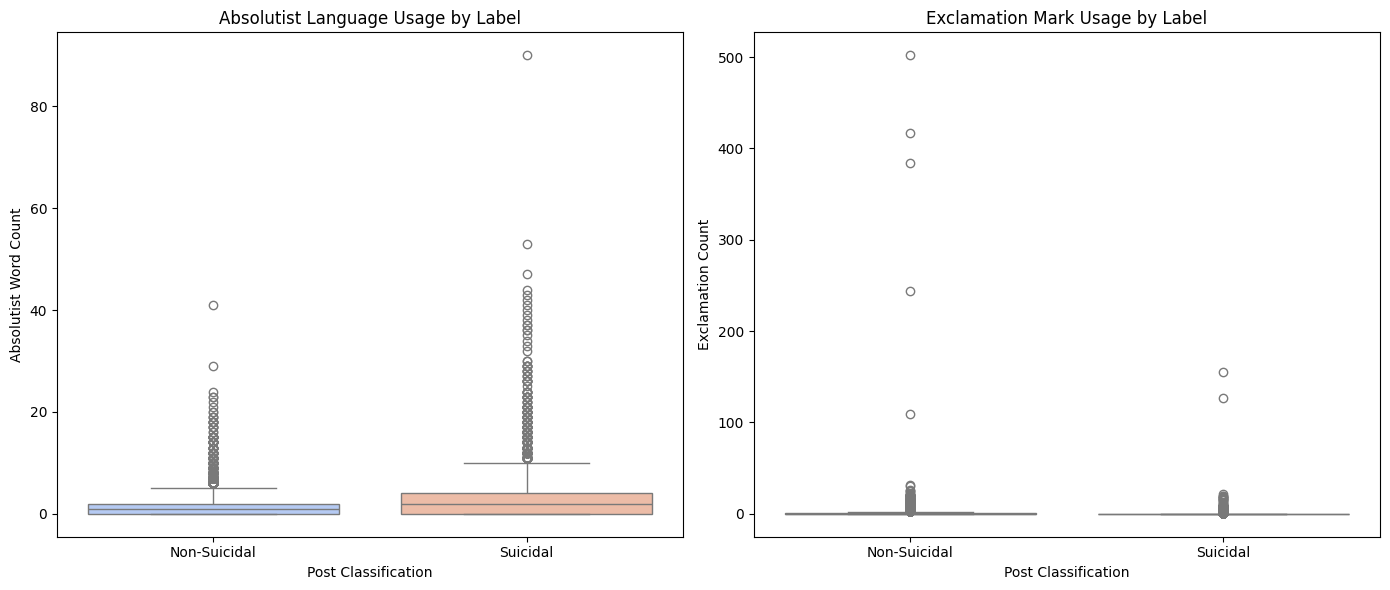

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='label', y='absolutist_count', palette='coolwarm', ax=axes[0])
axes[0].set_title('Absolutist Language Usage by Label')
axes[0].set_xlabel('Post Classification')
axes[0].set_ylabel('Absolutist Word Count')

sns.boxplot(data=df, x='label', y='exclamation_count', palette='coolwarm', ax=axes[1])
axes[1].set_title('Exclamation Mark Usage by Label')
axes[1].set_xlabel('Post Classification')
axes[1].set_ylabel('Exclamation Count')

plt.tight_layout()
plt.show()

For `absolutist_count`, the **Suicidal** box sits notably higher than the Non-Suicidal box, with a higher median and wider IQR — consistent with the mean difference. The spread also indicates that heavy absolutist language is common across a large portion of suicidal posts, not just outliers.

For `exclamation_count`, the pattern **reverses**: the Non-Suicidal group has a higher median and wider IQR, while the Suicidal box is compressed near zero. This indicates that suicidal posts are largely devoid of exclamations, reflecting a flat, resigned tone rather than heightened emotional expression.

The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** for `absolutist_count`. There is a statistically significant difference in absolutist language usage between Suicidal and Non-Suicidal posts.

The large positive t-statistic (22.58) confirms that Suicidal posts score substantially higher — this aligns with the cognitive distortion literature, where suicidal ideation is strongly associated with absolutist, black-and-white thinking (e.g., words like *"always"*, *"never"*, *"nothing"*, *"completely"*).

In [ ]:
suicidal_exc = df[df['label'] == 'Suicidal']['exclamation_count']
non_suicidal_exc = df[df['label'] == 'Non-Suicidal']['exclamation_count']

t_stat, p_value = stats.ttest_ind(suicidal_exc, non_suicidal_exc, equal_var=False)

print(f"Exclamation Usage — Welch's t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Exclamation Usage — Welch's t-statistic: -10.8607
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** for `exclamation_count` as well. There is a statistically significant difference — but notably, the **t-statistic is negative (−10.86)**, meaning the Suicidal group has a *lower* mean than the Non-Suicidal group.

This reveals that exclamation marks are not an indicator of emotional distress in suicidal posts. Rather, their near-absence in suicidal content reflects a tone of **emotional flatness and resignation** — a stark contrast to the expressive, energetic punctuation style more typical of casual non-suicidal discourse.


---

## Conclusion: Emotional Vocabulary vs. Grammatical Structure in Suicidal Posts

The central question of this EDA was:

> **Does the 'Suicidal' label manifest more through emotional vocabulary or through 
> specific grammatical structures (like self-focus and punctuation usage)?**

Across all four EDA questions, every feature showed a statistically significant 
difference between Suicidal and Non-Suicidal posts (all p < 0.05). The findings 
are summarized below:

| Feature | Suicidal Mean | Non-Suicidal Mean | Ratio | t-statistic | Significant? |
|---|---|---|---|---|---|
| `negative_emotion` | 0.940 | 0.241 | 3.9× higher | +35.96 | Yes |
| `first_person_singular` | 20.681 | 11.837 | 1.7× higher | +26.46 | Yes |
| `death_related` | 1.811 | 0.125 | 14.5× higher | +13.19 | Yes |
| `absolutist_count` | 3.066 | 1.776 | 1.7× higher | +22.58 | Yes |
| `exclamation_count` | 0.188 | 1.328 | 7.1× **lower** | −10.86 | Yes |

### Answer

The evidence points to **both** dimensions playing a role, but **emotional vocabulary 
is the stronger and more discriminative signal**:

- `death_related` showed the largest raw separation (14.5× difference), making it 
  the single most discriminative feature in this analysis. A post containing explicit 
  death-related language is far more likely to be Suicidal than Non-Suicidal.
- `negative_emotion` also showed a strong 3.9× gap, confirming that suicidal posts 
  are saturated with negative emotional language broadly, not just death-specific terms.

Grammatical structure also plays a meaningful role, but in a more nuanced way:

- `first_person_singular` is elevated in Suicidal posts (1.7×), consistent with the 
  known psychological pattern of self-focused rumination in suicidal ideation.
- `absolutist_count` is elevated (1.7×), reflecting the rigid, all-or-nothing thinking 
  commonly associated with suicidal cognition.
- `exclamation_count` is markedly **lower** in Suicidal posts (7.1×), revealing that 
  suicidal language is tonally flat and resigned — not emotionally explosive.

### Key Takeaway

Suicidal posts are best characterized by a combination of **what words are used** 
(death-related and negative emotional vocabulary) and **how language is structured** 
(self-focused, absolutist, and devoid of expressive punctuation). If forced to choose 
one dimension, emotional vocabulary — particularly death-related language — is the 
stronger differentiator. However, the grammatical markers (especially the *absence* 
of exclamation marks) add meaningful signal that emotional vocabulary alone does not 
capture.

To be able to analyze the emotional tone of the data, we can look at the distribution of the `negative_emotion` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent negative emotional language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [9]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['negative_emotion'].mean())

label
Non-Suicidal    0.241190
Suicidal        0.940069
Name: negative_emotion, dtype: float64


- Non-suicidal mean negative emotion = 0.241
- Suicidal mean negative emotion = 0.940

This means posts labaled suicidal have, on average about 3.9x higher than non suicidal posts. This can potentiall indicate that negative emotional language is associated with suicidal labels

To better visualize it, we create a boxplot showcasing the comparison across the 2 labels

/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_80831/1436483550.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')


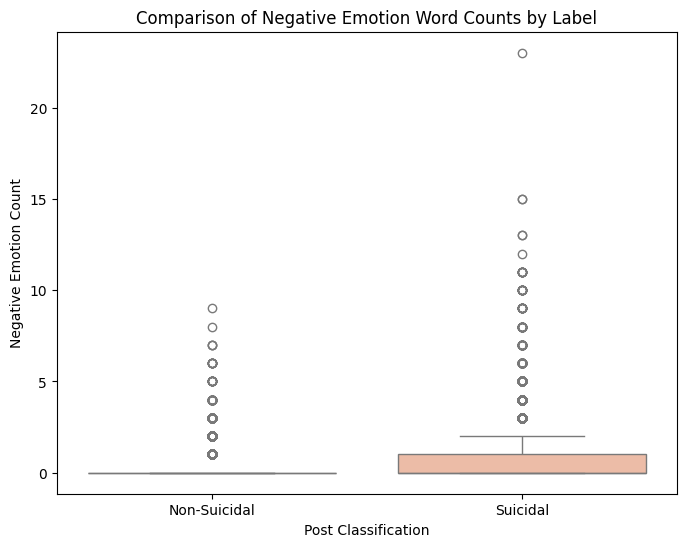

In [10]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='negative_emotion', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Negative Emotion Count')
plt.show()

From the boxplot, the **Suicidal** group is shifted upward compared with the **Non-Suicidal** group, meaning its median and most values of `negative_emotion` are higher.

The box (IQR) for Suicidal posts is also at higher values, which shows that even the middle 50% of that group tends to use more negative-emotion language.

There may still be some overlap between groups, but the clear upward shift supports the earlier mean comparison and suggests a strong association between higher `negative_emotion` and the suicidal label.

### Why we use a t-test here
We use a **Welch’s independent-samples t-test** to verify whether the difference in average `negative_emotion` between **Suicidal** and **Non-Suicidal** posts is statistically meaningful, not just due to random variation.

### How it works
- It compares the two group means relative to how spread out the scores are within each group.
- **Null hypothesis ($H_0$):** both groups have the same true mean `negative_emotion`.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (size of difference in standardized units) and a **p-value** (how likely that difference is if $H_0$ were true).

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [17]:
suicidal_emo = df[df['label'] == 'Suicidal']['negative_emotion']
non_suicidal_emo = df[df['label'] == 'Non-Suicidal']['negative_emotion']

t_stat, p_value = stats.ttest_ind(suicidal_emo, non_suicidal_emo, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 35.9569
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)




In our output, the p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude there is a statistically significant difference in mean `negative_emotion` between the two labels.
The Welch's t-test also showed that there is a statistically significant difference between first-person 

---

## EDA Question 2: Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?

<introduction>

In [12]:
# Calculate the mean first_person_singular for each label
print("Mean first_person_singular by label:")
print(df.groupby('label')['first_person_singular'].mean())

Mean first_person_singular by label:
label
Non-Suicidal    11.836727
Suicidal        20.680687
Name: first_person_singular, dtype: float64


/var/folders/2f/bn57x__n17l0rr82f5xx7h680000gn/T/ipykernel_80831/4252779587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')


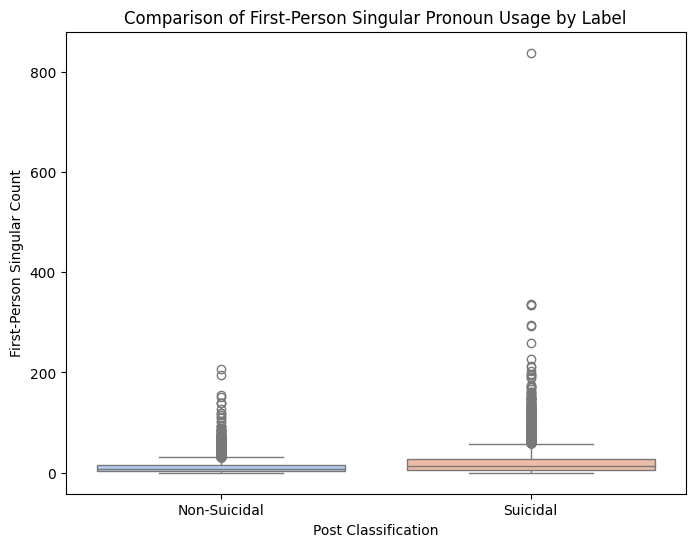

In [13]:
# Boxplot: first_person_singular across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='first_person_singular', palette='coolwarm')

plt.title('Comparison of First-Person Singular Pronoun Usage by Label')
plt.xlabel('Post Classification')
plt.ylabel('First-Person Singular Count')
plt.show()

In [14]:
suicidal_fp = df[df['label'] == 'Suicidal']['first_person_singular']
non_suicidal_fp = df[df['label'] == 'Non-Suicidal']['first_person_singular']

t_stat, p_value = stats.ttest_ind(suicidal_fp, non_suicidal_fp, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 26.4571
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between first-person 

---

## EDA Question 3: Is there a statistically significant difference in the death related word usage between the two labels?
<introduction>

In [18]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['death_related'].mean())

label
Non-Suicidal    0.125107
Suicidal        1.811271
Name: death_related, dtype: float64


In [ ]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='death_related', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Death Related Count')
plt.show()